# DDROM for MHD: Offline Phase - 2 (Training GPR)
This notebook implements the Training Phase for the Gaussian Process Regression on the POD coefficients.

In [1]:
import numpy as np
import pickle
import GPy
from gpr import GPR

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm

plt.rcParams.update({
  "text.usetex": True,
  "font.family": "serif"
})

rcParams['text.latex.preamble'] = r'\usepackage{amssymb} \usepackage{amsmath} \usepackage{amsthm} \usepackage{mathtools}'

path='./Offline_results/'
path_FOM = './Snapshots/'

Let us import the training POD coefficients

In [2]:
var_names = ['p_red', 'U']
tex_var_names = [r'\tilde{p}', r'\mathbf{u}']
tmp = pickle.load(open(path_FOM+'/snap.params', 'rb'))
params = {'p_red': tmp[0]['p'], 'U': tmp[1]['U']}
del tmp

train_pod_coeffs = pickle.load(open(path+'/coeffs.POD', 'rb'))

## Training monolithic GPR
In this section, we are going to train the GPR models using both tensor decomposition and monolithic approach

In [3]:
Nmax = 20

input_dim = 2
sampling = 2
cut = train_pod_coeffs.shape[1]

gpr_models = list()
for field_i in range(len(var_names)):
    sorting_idx = [int(train_pod_coeffs[field_i,ll,0]) for ll in range(train_pod_coeffs[field_i, :,0].shape[0])]
    gpr_train_X = params[var_names[field_i]][sorting_idx].reshape(-1,input_dim)[:cut:sampling]
    
    gpr_models.append(dict())
    for nn in range(Nmax):
        gpr_train_y = train_pod_coeffs[field_i, :, nn+1].reshape(-1,1)[:cut:sampling]

        gpr_models[field_i]['Rank '+str(nn+1)] = GPR(gpr_train_X, gpr_train_y, kernel=GPy.kern.RBF(input_dim=input_dim, variance=0.1, ARD=False),
                                            normalisation={'X': 'min-max', 'y': 'std'})
                                            # normalisation={'X': None, 'y': None})
                                            
        gpr_models[field_i]['Rank '+str(nn+1)].optimize(restart=5)

Let us store the data and make some plots for comparison

In [4]:
pickle.dump(gpr_models, open(path+'gpr.models', 'wb'))

for field_i in range(len(var_names)):
    nrows = 3
    ncols = 3
    fig, axs = plt.subplots(nrows = nrows, ncols = ncols, sharex=True, figsize=(6 * ncols, 5 * nrows),
                            subplot_kw={"projection": "3d"})
    axs = axs.flatten()

    xx = np.linspace(np.min(gpr_train_X, axis=0)[0], np.max(gpr_train_X, axis=0)[0], 100)
    yy = np.linspace(0, np.max(gpr_train_X, axis=0)[1], 300)

    X_grid, Y_grid = np.meshgrid(xx, yy) 
    gpr_input = np.column_stack([X_grid.flatten(), Y_grid.flatten()])

    for nn in range(nrows * ncols):
        mean, _ = gpr_models[field_i]['Rank '+str(nn+1)].predict(gpr_input)
        gpr_output = mean.reshape(X_grid.shape)
        axs[nn].plot_surface(X_grid, Y_grid, gpr_output, cmap=cm.viridis)

        axs[nn].scatter(gpr_train_X[:,0], gpr_train_X[:,1], train_pod_coeffs[field_i, :, nn+1].reshape(-1,1)[:cut:sampling], color='black')
        
    fig.subplots_adjust(hspace=0.05)
    fig.savefig(path+'/gpr_'+var_names[field_i]+'_podcoeff.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.close(fig)

## Training tensor-decomposition-base GPR
In this section the tensor decomposition is used to learn two different maps on 1D inputs, instead of a single 2D map.

In [6]:
input_dim = 2

gpr_td_models = {var_names[0]: list(), var_names[1]: list()}

for field_i in range(len(var_names)):
    sampling = 2
    sorting_idx = [int(train_pod_coeffs[field_i,ll,0]) for ll in range(train_pod_coeffs[field_i, :,0].shape[0])]
    gpr_train_2D_X = params[var_names[field_i]][sorting_idx].reshape(-1,input_dim)[::sampling]
    gpr_test_2D_X = params[var_names[field_i]][sorting_idx].reshape(-1,input_dim)[1::sampling]

    # Get unique values for each column without repetition
    unique_values_per_column = [np.unique(gpr_train_2D_X[:, i]) for i in range(gpr_train_2D_X.shape[1])]
    By_gpr_train = unique_values_per_column[0].reshape(-1,1)
    t_gpr_train = unique_values_per_column[1].reshape(-1,1)

    for nn in range(Nmax):
        gpr_td_models[var_names[field_i]].append({'t': dict(), 'By': dict()})
        Ql = np.zeros((len(t_gpr_train), len(By_gpr_train)))

        kk = 0
        for By in range(len(By_gpr_train)):
            for tt in range(len(t_gpr_train)):
                Ql[tt, By] = train_pod_coeffs[field_i, kk, nn+1]
                kk += sampling
                
        u,s,vh = np.linalg.svd(Ql, full_matrices=False)
        rank_svd = 6

        psi_l = u[:, :rank_svd]
        lambda_l = s[:rank_svd]
        phi_l = vh[:rank_svd]
        
        gpr_td_models[var_names[field_i]][nn]['Sing_vals'] = lambda_l

        ####### Training Tensor-Decomposed models #######
        for ll in range(rank_svd):
            gpr_td_models[var_names[field_i]][nn]['t']['Rank '+str(ll+1)]  = GPR(t_gpr_train,  psi_l[:, ll].reshape(-1,1), kernel=GPy.kern.RBF(input_dim=1, variance=0.1, ARD=False), normalisation = {'X': 'min-max', 'y': 'std'})
            gpr_td_models[var_names[field_i]][nn]['By']['Rank '+str(ll+1)] = GPR(By_gpr_train, phi_l[ll].reshape(-1,1), kernel=GPy.kern.RBF(input_dim=1, variance=0.1, ARD=False), normalisation = {'X': 'min-max', 'y': 'std'})
            
            gpr_td_models[var_names[field_i]][nn]['t']['Rank '+str(ll+1)].optimize( restart=5, messages=False)
            gpr_td_models[var_names[field_i]][nn]['By']['Rank '+str(ll+1)].optimize(restart=5, messages=False)

Let us plot each model

In [7]:
pickle.dump(gpr_td_models, open(path+'gpr_tens_dec.models', 'wb'))

def gpr_tens_predict(gpr_mods: dict, t_: np.ndarray, By_: np.ndarray, ):
    
    t_  = t_.reshape(-1,1)
    By_ = By_.reshape(-1,1)
    
    lambda_l = gpr_mods['Sing_vals']
    rank_svd = len(lambda_l)
    
    u_  = np.zeros((len(t_),  rank_svd))
    vh_ = np.zeros((rank_svd, len(By_)))    

    for ll in range(rank_svd):
        u_[:, ll] = gpr_mods['t']['Rank '+str(ll+1)](t_)
        vh_[ll]   = gpr_mods['By']['Rank '+str(ll+1)](By_)

    return np.dot(u_, np.dot(np.diag(lambda_l), vh_))

xx = np.linspace(np.min(By_gpr_train, axis=0), np.max(By_gpr_train, axis=0)[0], 100)
yy = np.linspace(0, np.max(t_gpr_train, axis=0), 300)

##############################################################################################################

for field_i in range(len(var_names)):
    nrows = 3
    ncols = 3
    fig, axs = plt.subplots(nrows = nrows, ncols = ncols, sharex=True, figsize=(6 * ncols, 5 * nrows),
                            subplot_kw={"projection": "3d"})
    axs = axs.flatten()

    X_grid, Y_grid = np.meshgrid(xx, yy) 

    for nn in range(nrows * ncols):
        gpr_output = gpr_tens_predict(gpr_td_models[var_names[field_i]][nn], yy, xx)
        axs[nn].plot_surface(X_grid, Y_grid, gpr_output, cmap=cm.viridis)

        axs[nn].scatter(gpr_train_2D_X[:,0], gpr_train_2D_X[:,1], train_pod_coeffs[field_i, :, nn+1].reshape(-1,1)[::sampling], color='blue')
        axs[nn].scatter(gpr_test_2D_X[:,0], gpr_test_2D_X[:,1], train_pod_coeffs[field_i, :, nn+1].reshape(-1,1)[1::sampling], color='red')
        
    fig.subplots_adjust(hspace=0.05)
    fig.savefig(path+'/gpr_tensdec_'+var_names[field_i]+'_podcoeff.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.close(fig)

## Post Process
In this section the GPR models will be plotted using 1D line plots for better visualisation.

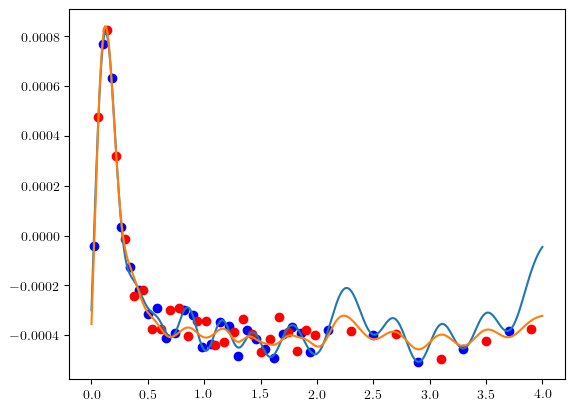

In [17]:
field_i = 1

idx_By = 0
nn = 2
time_samples = 60
By_samples   = 11

gpr_train_2D_X = params[var_names[field_i]][sorting_idx].reshape(-1,input_dim)[idx_By * time_samples     : (idx_By+1) * time_samples : sampling]
gpr_test_2D_X  = params[var_names[field_i]][sorting_idx].reshape(-1,input_dim)[idx_By * time_samples + 1 : (idx_By+1) * time_samples : sampling]

train_pod_coeff = train_pod_coeffs[field_i, :, nn+1].reshape(-1,1)[idx_By * time_samples     : (idx_By+1) * time_samples : sampling]
test_pod_coeff  = train_pod_coeffs[field_i, :, nn+1].reshape(-1,1)[idx_By * time_samples + 1 : (idx_By+1) * time_samples : sampling]

plt.scatter(gpr_train_2D_X[:,1], train_pod_coeff, color='blue')
plt.scatter(gpr_test_2D_X[:,1],  test_pod_coeff,  color='red')

gpr_input = np.vstack([gpr_train_2D_X[0,0] * np.ones((400)), np.linspace(0, 4, 400)]).T
mono_gpr_mean, _ = gpr_models[field_i]['Rank '+str(nn+1)].predict(gpr_input)   

td_gpr_mean = gpr_tens_predict(gpr_td_models[var_names[field_i]][nn], gpr_input[:,1], gpr_input[0,0])

plt.plot(gpr_input[:,1], mono_gpr_mean)
plt.plot(gpr_input[:,1], td_gpr_mean)